## **IMPORT LIBRARY**

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Model
import lightgbm as lgb

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold

## **SETUP FILE**

In [81]:
df = pd.read_csv("dataset/train.csv")
dft = pd.read_csv("dataset/test.csv")
baris, kolom = df.shape
print(f'Baris: {baris}, Kolom: {kolom}')
target = 'property_organic_content'
df.head()

Baris: 11210, Kolom: 52


,sample_id,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,...,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15
0,train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,train_00004,Source_02,YES,NO,Auger,0-20,N,Unknown,State_07,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,train_00005,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
# import pandas as pd
# import numpy as np

# df = pd.read_csv('dataset/train.csv')

# # Ekstrak nomor urut
# df['sample_num'] = df['sample_id'].str.extract(r'(\d+)').astype(int)

# # 1. Korelasi dengan target dan fitur numerik
# numeric_cols = df.select_dtypes(include='number').columns
# corr_with_sample = df[numeric_cols].corr()['sample_num'].drop('sample_num')
# print(corr_with_sample.abs().sort_values(ascending=False).head(15))

In [83]:
# # 2. Korelasi dengan fitur kategorikal — pakai ANOVA F-score
# from sklearn.feature_selection import f_classif

# # Encode sample_num jadi bins dulu supaya bisa diperlakukan sebagai "group"
# df['sample_bin'] = pd.cut(df['sample_num'], bins=10, labels=False)

# cat_cols = df.select_dtypes(exclude='number').columns.drop('sample_id')
# for col in cat_cols:
#     encoded = pd.Categorical(df[col]).codes
#     f, p = f_classif(encoded.reshape(-1,1), df['sample_bin'])
#     print(f"{col}: p-value = {p[0]:.4f} {'⚠️ KORELASI' if p[0] < 0.05 else '✅ aman'}")

## **HANDLE MISSING VALUES**

In [84]:
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
})

missing_df = missing_df[missing_df['missing_count'] > 0]
print(missing_df.sort_values(by='missing_percentage', ascending=False))

                          missing_count  missing_percentage
cation_Na                         10808           96.413916
spectral_band_B_PC_7               9516           84.888492
spectral_band_B_PC_5               9516           84.888492
spectral_band_B_PC_6               9516           84.888492
spectral_band_B_PC_4               9516           84.888492
spectral_band_B_PC_3               9516           84.888492
spectral_band_B_PC_2               9516           84.888492
spectral_band_B_PC_1               9516           84.888492
spectral_band_B_PC_12              9516           84.888492
spectral_band_B_PC_9               9516           84.888492
spectral_band_B_PC_10              9516           84.888492
spectral_band_B_PC_11              9516           84.888492
spectral_band_B_PC_14              9516           84.888492
spectral_band_B_PC_13              9516           84.888492
spectral_band_B_PC_15              9516           84.888492
spectral_band_B_PC_8               9516 

- cation Na hilang 96.4 % --> Drop aja
- spectral b rata hilang 84 % --> lihat isinya dulu
- latitude, longitude hilang 74% ++ --> impute?
- property_acidity_index ilang 74% ++ juga --> impute?

### **Drop cation Na**

In [85]:
df = df.drop(columns= 'cation_Na')
dft = dft.drop(columns= 'cation_Na')

print('cation_Na ilang')

cation_Na ilang


### **EDA Spectral B**

In [86]:
spectral_b_cols = []
for i in range(1,16):
    spektral = f'spectral_band_B_PC_{i}'
    spectral_b_cols.append(spektral)

spectral_b_cols_df = df[spectral_b_cols]

apakah saat salah satu spectral band b kosong, maka semua ikut kosong?

In [87]:
for i in range(1,16):
    ratakosong = df[spectral_b_cols].isnull().all(axis=1).equals(df[f'spectral_band_B_PC_{i}'].isnull())
    print(i, ratakosong)

1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True


True, berarti semua kolom missing barengan. artinya,
- salah satu data spectral b ga ada, makasemua data spectral b ga ada
- satu sumber (source_id) gapunya data spectral b

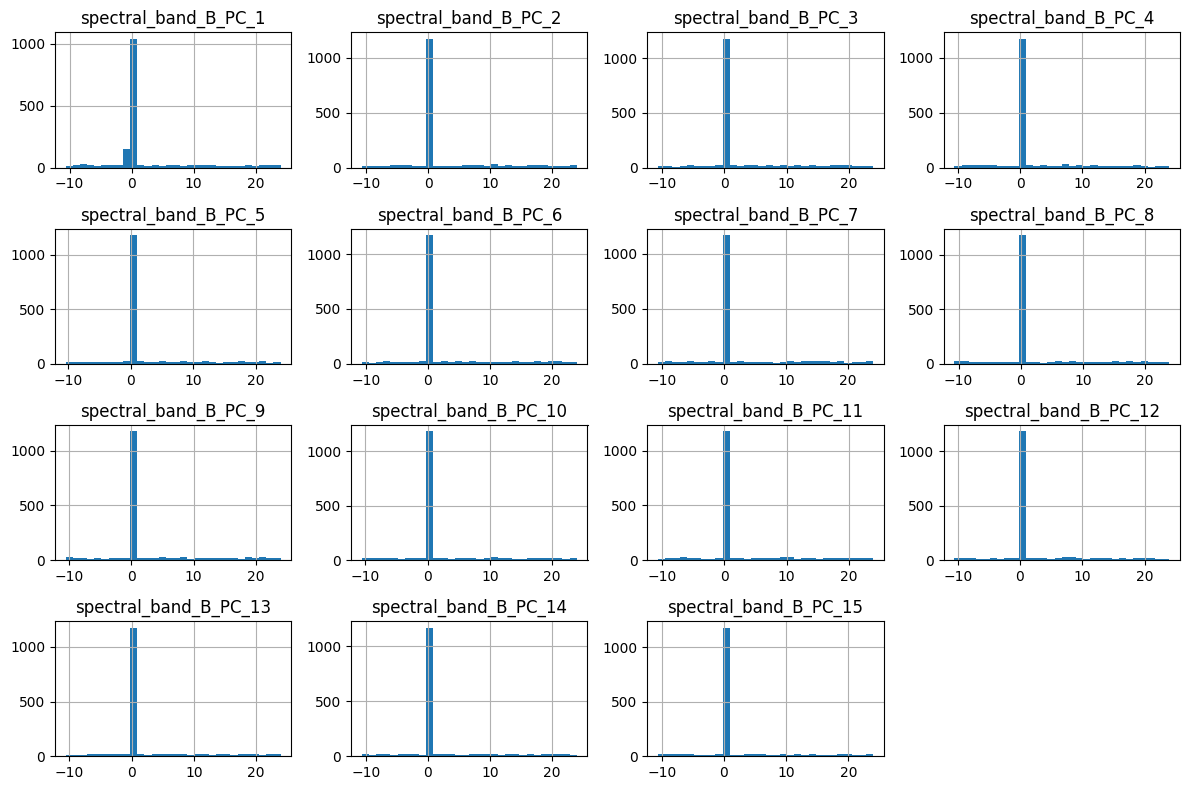

In [88]:
spectral_b_cols_df.dropna().hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

walaupun disitu dominan 0, tapi data yang hilang juga banyak (84%). maka ada 2 opsi, 
- biarin NaN dan tambahin flag aja
- flag + impute

coba2 aja

In [89]:
#FLAG
df['spectral_missing'] = df[spectral_b_cols].isna().all(axis=1).astype(int)
dft['spectral_missing'] = dft[spectral_b_cols].isna().all(axis=1).astype(int)

#IMPUTE
for col in spectral_b_cols:
    df[col] = df.groupby('source_id')[col]\
    .transform(lambda x: x.fillna(x.mean()))
    dft[col] = dft.groupby('source_id')[col]\
    .transform(lambda x: x.fillna(x.mean()))

    # df[col] = df[col].fillna(df[col].median())
    # dft[col] = dft[col].fillna(dft[col].median())

### **EDA Latitude, Longitude**

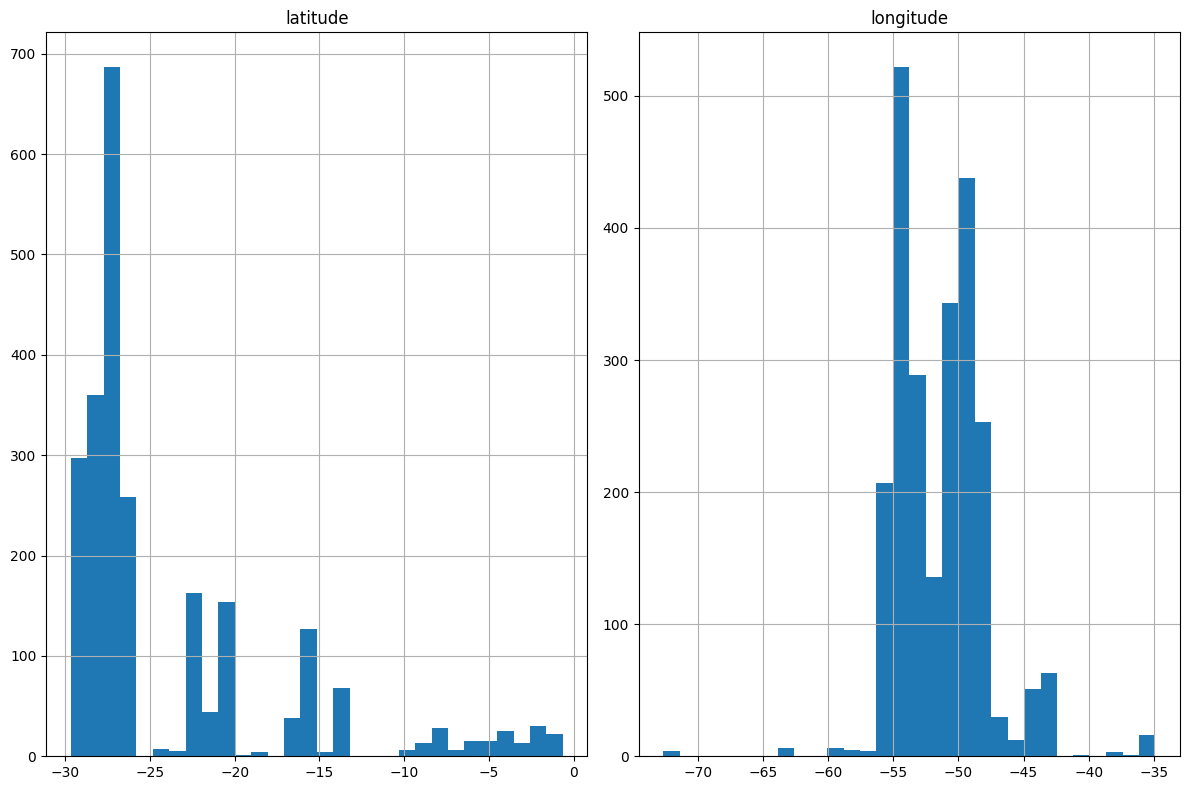

In [90]:
latlot_df = df[['latitude', 'longitude']]
latlot_df.dropna().hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

In [91]:
#Flag
df['geo_missing'] = df[['latitude', 'longitude']].isna().all(axis=1).astype(int)
dft['geo_missing'] = dft[['latitude', 'longitude']].isna().all(axis=1).astype(int)

# #Impute
# df['longitude'] = df.groupby(['geo_zone_macro', 'geo_zone_meso'])['longitude']\
#     .transform(lambda x: x.fillna(x.median()))
# df['latitude'] = df.groupby(['geo_zone_macro', 'geo_zone_meso'])['latitude']\
#     .transform(lambda x: x.fillna(x.median()))
# dft['longitude'] = dft.groupby(['geo_zone_macro', 'geo_zone_meso'])['longitude']\
#     .transform(lambda x: x.fillna(x.median()))
# dft['latitude'] = dft.groupby(['geo_zone_macro', 'geo_zone_meso'])['latitude']\
#     .transform(lambda x: x.fillna(x.median()))

df.groupby('geo_missing')[target].mean()

geo_missing
0    34.586032
1    34.022336
Name: property_organic_content, dtype: float64

### **EDA keasaman tanah**

In [92]:
df.groupby('parent_rock_type')['property_acidity_index'].agg(['count', 'size'])
df.groupby('parent_rock_type')['property_acidity_index'].agg(
    total='size',
    filled='count'
).assign(
    fill_rate=lambda x: x['filled'] / x['total']
)

dft.groupby('parent_rock_type')['property_acidity_index'].agg(['count', 'size'])
dft.groupby('parent_rock_type')['property_acidity_index'].agg(
    total='size',
    filled='count'
).assign(
    fill_rate=lambda x: x['filled'] / x['total']
)

,total,filled,fill_rate
parent_rock_type,,,
Igneous Rock,1280,424,0.331250
Metamorphic Rock,122,17,0.139344
Sedimentary Rock,857,213,0.248541
Unknown,411,47,0.114355


Bisa dilihat bahwa untuk satu tipe batu yang sama, tidak selalu memiliki data property_acidity_index. Maka, Coba
1. kasih flag + impute median groupby tipe batu induk
2. kasih flag aja

In [93]:
#Flag
df['acidity_missing'] = df['property_acidity_index'].isna().astype(int)
dft['acidity_missing'] = dft['property_acidity_index'].isna().astype(int)

#Impute
df['property_acidity_index'] = df.groupby('parent_rock_type')['property_acidity_index']\
    .transform(lambda x: x.fillna(x.median()))
dft['property_acidity_index'] = dft.groupby('parent_rock_type')['property_acidity_index']\
    .transform(lambda x: x.fillna(x.median()))

In [94]:
# df['geo_zone_macro'].unique()
df['geo_zone_meso'].unique
# df['geo_zone_micro'].unique

<bound method Series.unique of 0        State_01
1        State_10
2        State_06
3        State_07
4        State_06
           ...   
11205    State_08
11206    State_01
11207    State_01
11208    State_07
11209    State_01
Name: geo_zone_meso, Length: 11210, dtype: object>

### **EDA Ca, Mg, dan exc**

In [95]:
#Flag
df['missing_Ca'] = df['cation_Ca'].isna().astype(int)
df['missing_Mg'] = df['cation_Mg'].isna().astype(int)
df['missing_exchange_capacity'] = df['cation_exchange_capacity'].isna().astype(int)

dft['missing_Ca'] = dft['cation_Ca'].isna().astype(int)
dft['missing_Mg'] = df['cation_Mg'].isna().astype(int)
dft['missing_exchange_capacity'] = dft['cation_exchange_capacity'].isna().astype(int)

#Impute
df['cation_Ca'] = df.groupby(['parent_rock_type'])['cation_Ca']\
                    .transform(lambda x: x.fillna(x.median()))
df['cation_Mg'] = df.groupby(['parent_rock_type'])['cation_Mg']\
                    .transform(lambda x: x.fillna(x.median()))
df['cation_exchange_capacity'] = df.groupby(['parent_rock_type'])['cation_exchange_capacity']\
                    .transform(lambda x: x.fillna(x.median()))

dft['cation_Ca'] = dft.groupby(['parent_rock_type'])['cation_Ca']\
                    .transform(lambda x: x.fillna(x.median()))
dft['cation_Mg'] = dft.groupby(['parent_rock_type'])['cation_Mg']\
                    .transform(lambda x: x.fillna(x.median()))
dft['cation_exchange_capacity'] = dft.groupby(['parent_rock_type'])['cation_exchange_capacity']\
                    .transform(lambda x: x.fillna(x.median()))

# Impute sisa
df['cation_Ca'] = df['cation_Ca'].fillna(df['cation_Ca'].median())
df['cation_Mg'] = df['cation_Mg'].fillna(df['cation_Mg'].median())
df['cation_exchange_capacity'] = df['cation_exchange_capacity'].fillna(df['cation_exchange_capacity'].median())

dft['cation_Ca'] = dft['cation_Ca'].fillna(dft['cation_Ca'].median())
dft['cation_Mg'] = dft['cation_Mg'].fillna(dft['cation_Mg'].median())
dft['cation_exchange_capacity'] = dft['cation_exchange_capacity'].fillna(dft['cation_exchange_capacity'].median())

### **Tambahan : Flag buat biome, parent rock type, land cover type, dll**

In [96]:
df['rock_missing'] = (df['parent_rock_type'] == 'Unknown').astype(int)
df['biome_missing'] = (df['biome'] == 'Unknown').astype(int)
df['land_missing'] = (df['land_cover_type'] == 'Unknown').astype(int)

dft['rock_missing'] = (dft['parent_rock_type'] == 'Unknown').astype(int)
dft['biome_missing'] = (dft['biome'] == 'Unknown').astype(int)
dft['land_missing'] = (dft['land_cover_type'] == 'Unknown').astype(int)

### **Cek Ulang missing Value**

In [97]:
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
})

missing_df = missing_df[missing_df['missing_count'] > 0]
print(missing_df.sort_values(by='missing_percentage', ascending=False))

                          missing_count  missing_percentage
latitude                           8820           78.679750
longitude                          8820           78.679750
property_particle_fine              767            6.842105
property_particle_coarse            752            6.708296
spectral_band_B_PC_1                 41            0.365745
spectral_band_B_PC_2                 41            0.365745
spectral_band_B_PC_3                 41            0.365745
spectral_band_B_PC_4                 41            0.365745
spectral_band_B_PC_5                 41            0.365745
spectral_band_B_PC_6                 41            0.365745
spectral_band_B_PC_7                 41            0.365745
spectral_band_B_PC_8                 41            0.365745
spectral_band_B_PC_9                 41            0.365745
spectral_band_B_PC_10                41            0.365745
spectral_band_B_PC_11                41            0.365745
spectral_band_B_PC_12                41 

### **FEATURE ENGINEERING**

In [98]:
def engineer_features(df: pd.DataFrame, ref_df: pd.DataFrame = None) -> pd.DataFrame:
    df = df.copy()
    
    spec_A_cols = [f'spectral_band_A_PC_{i}' for i in range(1, 16) if f'spectral_band_A_PC_{i}' in df.columns]
    spec_B_cols = [f'spectral_band_B_PC_{i}' for i in range(1, 16) if f'spectral_band_B_PC_{i}' in df.columns]
    
    # 1. Energi spektrum (L2-norm)
    # if spec_A_cols:
    #     df['band_A_energy'] = np.sqrt(np.nansum(df[spec_A_cols].values ** 2, axis=1))
    # if spec_B_cols:
    #     df['band_B_energy'] = np.sqrt(np.nansum(df[spec_B_cols].values ** 2, axis=1))
    
    # 2. Rasio spektrum PC dominan -- PAKE
    if 'spectral_band_A_PC_1' in df.columns and 'spectral_band_A_PC_2' in df.columns:
        df['spectral_ratio_A1_A2'] = df['spectral_band_A_PC_1'] / (np.abs(df['spectral_band_A_PC_2']) + 1e-8)
    
    # 3. Kontras spektrum AB -- PAKE
    if 'band_A_energy' in df.columns and 'band_B_energy' in df.columns:
        df['band_AB_contrast'] = np.abs(df['band_A_energy'] - df['band_B_energy'])
    
    # 4. Rasio Ca ke Mg (selisih nilai log)
    # if 'cation_Ca_log1p' in df.columns and 'cation_Mg_log1p' in df.columns:
    #     df['cation_Ca_Mg_diff'] = df['cation_Ca_log1p'] - df['cation_Mg_log1p']
    
    # 5. Total kation terlarut (gabungan log)
    # if all(c in df.columns for c in ['cation_Ca_log1p', 'cation_Mg_log1p', 'cation_Na_log1p']):
    #     df['cation_total_log'] = df['cation_Ca_log1p'].fillna(0) + df['cation_Mg_log1p'].fillna(0) + df['cation_Na_log1p'].fillna(0)
    
    # 6. CEC per partikel halus (proksi tanah liat)
    # if 'cation_exchange_capacity_log1p' in df.columns and 'property_particle_fine' in df.columns:
    #     df['CEC_per_clay'] = df['cation_exchange_capacity_log1p'] / (df['property_particle_fine'] + 1e-8)
    
    # 7. Rasio tekstur dan total partikel
    if 'property_particle_coarse' in df.columns and 'property_particle_fine' in df.columns:
        df['particle_ratio'] = df['property_particle_coarse'] / (df['property_particle_fine'] + 1e-8) #-- pake
        # df['particle_sum']   = df['property_particle_coarse'].fillna(0) + df['property_particle_fine'].fillna(0)
    
    # 8. Interaksi geografis --PAKE
    if 'latitude' in df.columns and 'longitude' in df.columns:
        df['geo_lat_lon_interaction'] = df['latitude'] * df['longitude']
        df['lat_abs'] = np.abs(df['latitude'])
    
    # 9. Porsi varians kumulatif Band A
    # if 'spectral_band_A_PC_1' in df.columns and 'spectral_band_A_PC_2' in df.columns and 'band_A_energy' in df.columns:
    #     df['band_A_PC1_PC2_share'] = (
    #         df['spectral_band_A_PC_1'].abs() + df['spectral_band_A_PC_2'].abs()
    #     ) / (df['band_A_energy'] + 1e-8)
        
    # 10. Interaksi keasaman dan kation -- PAKE
    if 'property_acidity_index' in df.columns and 'cation_total_log' in df.columns:
        df['acidity_cation_interaction'] = df['property_acidity_index'] * df['cation_total_log']
        
    # 11. Proksi Rasio Adsorpsi Natrium (SAR)
    # if all(c in df.columns for c in ['cation_Na_log1p', 'cation_Ca_log1p', 'cation_Mg_log1p']):
    #     df['SAR_proxy'] = df['cation_Na_log1p'] / np.sqrt(df['cation_Ca_log1p'] + df['cation_Mg_log1p'] + 1e-8)
        
    # 12. Indeks proksi iklim
    # if 'lat_abs' in df.columns and 'property_acidity_index' in df.columns:
    #     df['climate_proxy_index'] = df['lat_abs'] * df['property_acidity_index']
    
    return df

## **TRAIN**

In [99]:
cat_cols = df.select_dtypes(exclude='number').columns
df[cat_cols] = df[cat_cols].astype('category')
dft[cat_cols] = dft[cat_cols].astype('category')
df.dtypes

sample_id                    category
source_id                    category
has_band_A_spectrum          category
has_band_B_spectrum          category
sampling_strategy            category
sampling_depth_cm            category
geo_zone_macro               category
geo_zone_micro               category
geo_zone_meso                category
land_cover_type              category
biome                        category
parent_rock_type             category
property_particle_coarse      float64
property_particle_fine        float64
property_organic_content      float64
property_acidity_index        float64
cation_Ca                     float64
cation_Mg                     float64
cation_exchange_capacity      float64
latitude                      float64
longitude                     float64
spectral_band_A_PC_1          float64
spectral_band_A_PC_2          float64
spectral_band_A_PC_3          float64
spectral_band_A_PC_4          float64
spectral_band_A_PC_5          float64
spectral_ban

In [100]:
X = df.drop(columns = [target,'sampling_depth_cm', 'has_band_A_spectrum', 'sample_id'])
Xt = dft.drop(columns = ['sampling_depth_cm', 'has_band_A_spectrum', 'sample_id'])

X = engineer_features(X, ref_df=X)
Xt = engineer_features(Xt, ref_df=Xt)

# y = np.log1p(df[target])
y = df[target]
X.head()

,source_id,has_band_B_spectrum,sampling_strategy,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,biome,parent_rock_type,property_particle_coarse,...,missing_Ca,missing_Mg,missing_exchange_capacity,rock_missing,biome_missing,land_missing,spectral_ratio_A1_A2,particle_ratio,geo_lat_lon_interaction,lat_abs
0,Source_01,NO,Auger,SE,Unknown,State_01,Seasonal Semideciduous Forest,Mata Atlantica,Sedimentary Rock,2494.42246,...,0,0,0,0,0,0,1.287795,6.455285,NaN,NaN
1,Source_10,NO,Auger,MW,Loc_011,State_10,Savannah,Cerrado,Igneous Rock,NaN,...,1,1,1,0,0,0,-3.952121,NaN,1402.516465,28.392778
2,Source_04,NO,Auger,S,Loc_001,State_06,Unknown,Unknown,Unknown,NaN,...,1,1,1,1,1,1,-1.565746,NaN,NaN,NaN
3,Source_02,NO,Auger,N,Unknown,State_07,Unknown,Amazonia,Igneous Rock,1476.54730,...,0,0,0,0,0,1,1.467919,0.979167,NaN,NaN
4,Source_04,NO,Auger,S,Loc_001,State_06,Unknown,Unknown,Unknown,NaN,...,1,1,1,1,1,1,-12.243174,NaN,NaN,NaN


In [101]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmse = []
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 33,
    'feature_fraction': 0.8,
    'verbose': -1,
    'random_state': 42
}

oof_pred = np.zeros(len(X))
test_pred = np.zeros(len(Xt))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )
    oof_pred[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_pred += model.predict(Xt) / kf.n_splits
    rmse = np.sqrt(mean_squared_error(y_val, oof_pred[val_idx]))
    fold_rmse.append(rmse)

np.mean(fold_rmse)

Fold 1
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 8.87969	valid's rmse: 11.449
[200]	train's rmse: 7.24082	valid's rmse: 11.1771
[300]	train's rmse: 6.25958	valid's rmse: 11.0844
[400]	train's rmse: 5.56196	valid's rmse: 11.0061
[500]	train's rmse: 4.96165	valid's rmse: 10.9551
Early stopping, best iteration is:
[547]	train's rmse: 4.7173	valid's rmse: 10.9314
Fold 2
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 8.8714	valid's rmse: 11.7456
[200]	train's rmse: 7.25953	valid's rmse: 11.3944
[300]	train's rmse: 6.3343	valid's rmse: 11.2906
[400]	train's rmse: 5.62265	valid's rmse: 11.223
[500]	train's rmse: 5.01083	valid's rmse: 11.1811
[600]	train's rmse: 4.49164	valid's rmse: 11.1774
[700]	train's rmse: 4.07524	valid's rmse: 11.1581
[800]	train's rmse: 3.71349	valid's rmse: 11.1593
Early stopping, best iteration is:
[820]	train's rmse: 3.65443	valid's rmse: 11.1541
Fold 3
Training until validation scores don't imp

np.float64(11.526993778680428)

In [102]:
rmse = np.sqrt(mean_squared_error(y, oof_pred))
print("OOF RMSE:", rmse)

OOF RMSE: 11.543064751539768


- awal = 11.436939660985386
- awal (no impute band b) = 11.485621218029852
- awal + imputasi multigroup = 11.50559923642648
- with imputasi Ca, Mg, exc + multigroup = 11.562517555998975
- with imputasi Ca, Mg, exc = 11.49403689381429

- feature engineering = 11.40504013485333

- last = 11.381027553072125

### **OVERFIT CHECK**

In [103]:
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, val_data],
)

### **FEATURE IMPORTANCE**

In [104]:
importances = model.feature_importance(importance_type='gain')

feature_names = model.feature_name()

for name, val in zip(feature_names, importances):
    print(f"{name}: {val}")

source_id: 11272881.687011719
has_band_B_spectrum: 0.0
sampling_strategy: 264078.6385498047
geo_zone_macro: 105909.86950683594
geo_zone_micro: 1157948.1281738281
geo_zone_meso: 2278068.8376464844
land_cover_type: 205922.25927734375
biome: 70276.83569335938
parent_rock_type: 1484.199951171875
property_particle_coarse: 4271425.887084961
property_particle_fine: 2950043.963684082
property_acidity_index: 32843.900390625
cation_Ca: 932966.3634033203
cation_Mg: 612046.409362793
cation_exchange_capacity: 3331363.349304199
latitude: 5525.4300537109375
longitude: 15275.479736328125
spectral_band_A_PC_1: 463091.18798828125
spectral_band_A_PC_2: 739020.8003540039
spectral_band_A_PC_3: 921942.5037231445
spectral_band_A_PC_4: 161308.0111694336
spectral_band_A_PC_5: 1216086.5647583008
spectral_band_A_PC_6: 417973.0603027344
spectral_band_A_PC_7: 403498.19958496094
spectral_band_A_PC_8: 200731.5499267578
spectral_band_A_PC_9: 511181.6394042969
spectral_band_A_PC_10: 244128.44036865234
spectral_band_A_

In [105]:
# submission
submission = pd.DataFrame({
    'sample_id': dft['sample_id'],
    'property_organic_content': test_pred
})

submission.to_csv('test5.csv', index=False)